In [7]:
import numpy as np

A = np.array([[1,2,3],[0,-4,1],[0,3,-1]],dtype=float)

det = np.linalg.det(A)
print(det)

B = np.array([2,2,1],dtype=float)
x = np.linalg.solve(A,B)
print(x)

AT = A.T @ A
I = np.eye(3)
o = np.allclose(AT,I)
print(f"Is orthogonal: {o}")

eival, eivec = np.linalg.eig(A)
print(eival)
print(eivec)

1.0
[ 38.  -3. -10.]
Is orthogonal: False
[ 1.         -4.79128785 -0.20871215]
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [14]:
import numpy as np

E = np.array([[-0.06698874, -0.87275577, -0.48353891],
[ 0.49272847, -0.45034696,  0.74458463],
[-0.86760081, -0.1883746,   0.46019978]],dtype = float)

a = 192.25
d = 27.4

arad = np.radians(a)
drad = np.radians(d)

v = np.array([np.cos(drad)*np.cos(arad),np.cos(drad)*np.sin(arad),np.sin(drad)],dtype=float)

vn = np.linalg.norm(v)

v2 = E @ v

print(v)
print(vn)
print(v2)

[-0.86760081 -0.1883746   0.46019978]
1.0
[ 3.42052507e-09 -4.54291365e-09  9.99999996e-01]


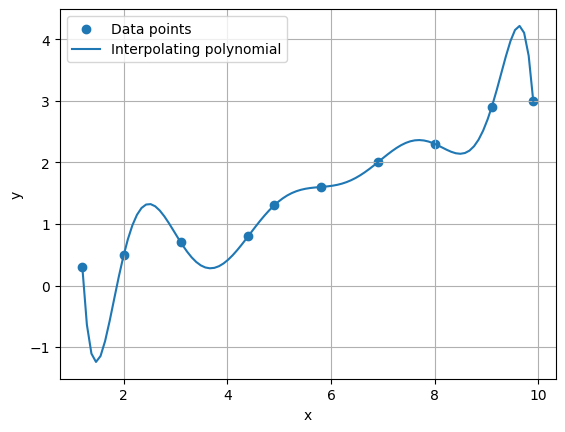

[1.2 2.  3.1 4.4 4.9 5.8 6.9 8.  9.1 9.9]


In [30]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)
A = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        A[i,j] = x[i]**(n - 1 - j)
        
c = np.linalg.solve(A,y)

xs = np.linspace(min(x),max(x),100)
yp = np.zeros_like(xs)

for i in range(n):
    yp += c[i] * xs**(n - 1 - i)
    
plt.scatter(x,y,label='Data points')
plt.plot(xs,yp,label='Interpolating polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(x)

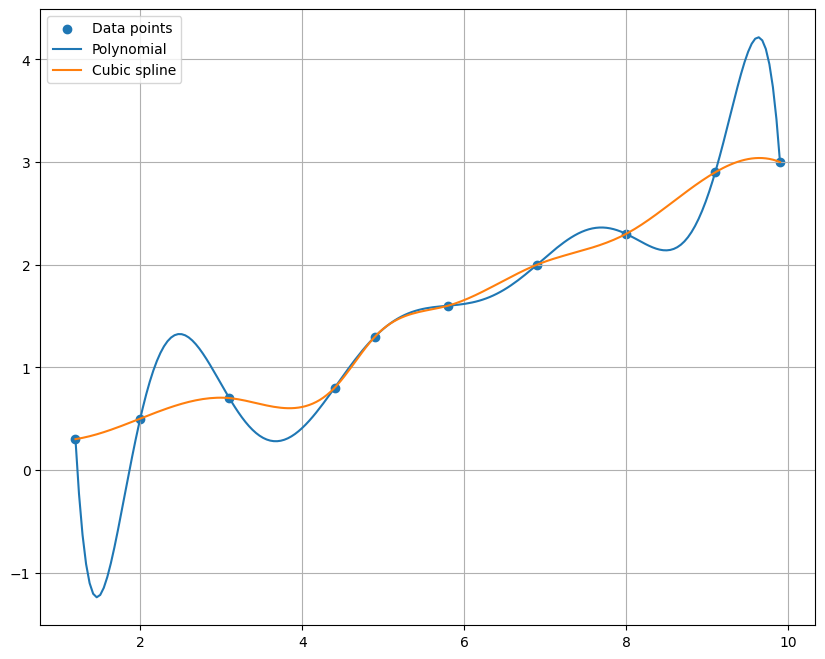

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

class Interpolation:
    def __init__(self,x,y):
        self.x=x
        self.y=y
        
        self.flin = interp1d(x,y,kind='linear')
        
        deg = len(x) - 1
        self.poly_coeffs = np.polyfit(x,y,deg)
        self.f_poly = np.poly1d(self.poly_coeffs)
        
        self.f_spline = interp1d(x,y,kind='cubic')
        
    def predict(self, xv,method='spline'):
        if method == 'linear':
            return self.f_linear(xv)
        elif method == 'poly':
            return self.f_poly(xv)
        elif method == 'spline':
            return self.f_spline(xv)
        else:
            return "method not found"
        
xd = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
yd = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

model = Interpolation(xd,yd)

xp = np.linspace(xd.min(),xd.max(),200)

plt.figure(figsize=(10,8))
plt.scatter(xd,yd,label='Data points')
plt.plot(xp,model.predict(xp,'poly'),label='Polynomial')
plt.plot(xp,model.predict(xp,'spline'),label='Cubic spline')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
import numpy as np
i00 = 2.0
i10 = 4.1
i01 = 2.5
i11 = 3.8

x = 0.2
y = 0.7

intens = (i00 * (1 - x) * (1 - y) + i10 * x * (1 - y) + i01 * (1 - x) * y + i11 * x * y)

print(intens)

2.658
